<a href="https://colab.research.google.com/github/vaidiknakrani/parul_AI_ML_Learning/blob/main/day_3_customer_segmentation_k_means_dbscan_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3 - Notebook 3: Customer Segmentation
## K-Means, DBSCAN & PCA (Unsupervised Learning)

**Parul University & TelcoLearn | AI-ML Training Program 2027**  
**Day 3 | July 15, 2025 | 2:30 PM - 4:30 PM**

---

## Objective
Group mall customers into natural segments WITHOUT using any labels.
This is unsupervised learning -- the algorithm must discover structure on its own.

| Step | What you do | What you learn |
|------|-------------|----------------|
| 1 | Load and explore data | 5 features, 200 customers |
| 2 | Elbow method | Find optimal K for KMeans |
| 3 | Silhouette score | Validate cluster quality |
| 4 | Train KMeans | Segment customers into groups |
| 5 | Profile clusters | What does each segment look like? |
| 6 | Visualise in 2D | PCA for cluster plots |
| 7 | DBSCAN | Find density-based clusters + outliers |
| 8 | PCA for compression | How many components keep 95% variance? |

**Dataset:** Mall Customer Segmentation  
**Kaggle path:** `/kaggle/input/customer-segmentation-tutorial-in-python/Mall_Customers.csv`  
**Dataset URL:** https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python  
**Why this dataset?** Classic, visual, interpretable. 5 features (Age, Income, Spending Score).
Clusters are visually obvious in 2D -- perfect for teaching when the maths works.

---
> **Key concept:** Unsupervised learning has no 'correct' answer.
> We evaluate clusters by how compact and well-separated they are,
> NOT by comparing to ground truth labels (which don't exist).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
import psutil
import pickle

process = psutil.Process(os.getpid())
warnings.filterwarnings('ignore')

from sklearn.cluster         import KMeans, DBSCAN
from sklearn.decomposition   import PCA
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import silhouette_score, davies_bouldin_score
from sklearn.neighbors       import NearestNeighbors

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid', palette='muted')
print('All imports successful.')

All imports successful.


In [ ]:
DATASET_PATH = '/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python'
# DATASET_PATH = '.'  # uncomment for local run

df = pd.read_csv(f'{DATASET_PATH}/Mall_Customers.csv')

print(f'Shape: {df.shape}')
print(f'\nFirst 5 rows:')
display(df.head())
print(f'\nDescriptive stats:')
display(df.describe())

Shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Descriptive stats:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


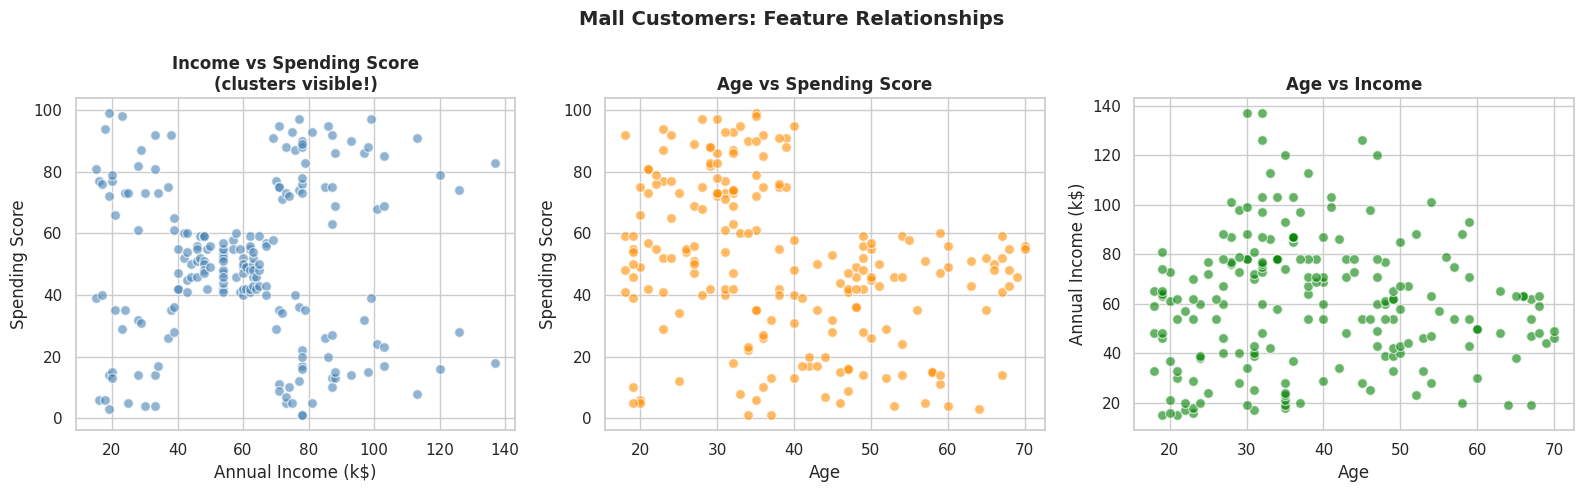

Key observation: Income vs Spending Score shows 5 natural clusters!
These are NOT labelled -- KMeans will discover them automatically.


In [ ]:
# EDA: pairplot to see natural structure
df_plot = df.copy()
df_plot['Gender_num'] = (df_plot['Gender'] == 'Male').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                c='steelblue', alpha=0.6, s=50, edgecolors='white')
axes[0].set_xlabel('Annual Income (k$)'); axes[0].set_ylabel('Spending Score')
axes[0].set_title('Income vs Spending Score\n(clusters visible!)', fontweight='bold')

axes[1].scatter(df['Age'], df['Spending Score (1-100)'],
                c='darkorange', alpha=0.6, s=50, edgecolors='white')
axes[1].set_xlabel('Age'); axes[1].set_ylabel('Spending Score')
axes[1].set_title('Age vs Spending Score', fontweight='bold')

axes[2].scatter(df['Age'], df['Annual Income (k$)'],
                c='green', alpha=0.6, s=50, edgecolors='white')
axes[2].set_xlabel('Age'); axes[2].set_ylabel('Annual Income (k$)')
axes[2].set_title('Age vs Income', fontweight='bold')

plt.suptitle('Mall Customers: Feature Relationships', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('Key observation: Income vs Spending Score shows 5 natural clusters!')
print('These are NOT labelled -- KMeans will discover them automatically.')

In [ ]:
# Prepare features for clustering
# Use Income + Spending Score for 2D analysis (most visually clear)
# Use all 3 numeric features for the full analysis

FEATURES_2D  = ['Annual Income (k$)', 'Spending Score (1-100)']
FEATURES_ALL = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

X_2d  = df[FEATURES_2D].values
X_all = df[FEATURES_ALL].values

# Always scale before clustering
scaler_2d  = StandardScaler()
scaler_all = StandardScaler()
X_2d_s  = scaler_2d.fit_transform(X_2d)
X_all_s = scaler_all.fit_transform(X_all)

print(f'2D features for visualisation: {FEATURES_2D}')
print(f'All features for full model  : {FEATURES_ALL}')
print(f'Data shape: {X_all_s.shape}')

2D features for visualisation: ['Annual Income (k$)', 'Spending Score (1-100)']
All features for full model  : ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
Data shape: (200, 3)


## Section 3 - Finding Optimal K

We use two methods:

**Elbow method:** Plot inertia (total within-cluster sum of squares) vs K.
Inertia always decreases as K increases. Look for the 'elbow' -- where
the rate of decrease slows sharply. That K is the sweet spot.

**Silhouette score:** For each point, measure how similar it is to its own
cluster vs the nearest other cluster. Range [-1, 1]. Higher = better.
s(i) = (b - a) / max(a, b) where a = mean distance to cluster-mates,
b = mean distance to nearest other cluster.

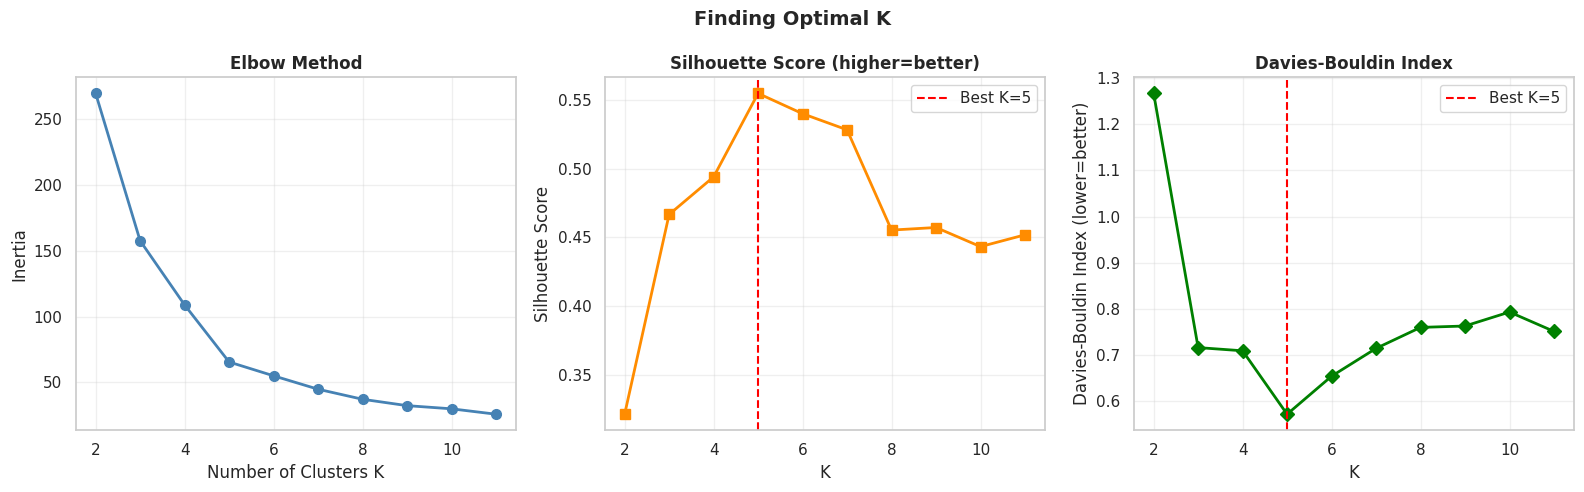

Best K by Silhouette : 5  (score=0.5547)
Best K by Davies-Bouldin: 5  (score=0.5722)


In [ ]:
# Elbow method + Silhouette scores
K_range    = range(2, 12)
inertias   = []
silhouette = []
davies_bouldin = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_2d_s)
    inertias.append(km.inertia_)
    silhouette.append(silhouette_score(X_2d_s, km.labels_))
    davies_bouldin.append(davies_bouldin_score(X_2d_s, km.labels_))

best_k_sil = list(K_range)[np.argmax(silhouette)]
best_k_db  = list(K_range)[np.argmin(davies_bouldin)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(K_range, inertias, 'steelblue', linewidth=2, marker='o', markersize=7)
axes[0].set_xlabel('Number of Clusters K'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette, 'darkorange', linewidth=2, marker='s', markersize=7)
axes[1].axvline(best_k_sil, color='red', linestyle='--',
                label=f'Best K={best_k_sil}')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher=better)', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(K_range, davies_bouldin, 'green', linewidth=2, marker='D', markersize=7)
axes[2].axvline(best_k_db, color='red', linestyle='--',
                label=f'Best K={best_k_db}')
axes[2].set_xlabel('K'); axes[2].set_ylabel('Davies-Bouldin Index (lower=better)')
axes[2].set_title('Davies-Bouldin Index', fontweight='bold')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Finding Optimal K', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Best K by Silhouette : {best_k_sil}  (score={max(silhouette):.4f})')
print(f'Best K by Davies-Bouldin: {best_k_db}  (score={min(davies_bouldin):.4f})')

In [ ]:
training_start = time.time()

K_FINAL = best_k_sil

km_final = KMeans(
    n_clusters=K_FINAL,
    init='k-means++',
    n_init=20,
    max_iter=300,
    random_state=42
)

km_final.fit(X_2d_s)

training_end = time.time()
kmeans_training_time = training_end - training_start

cpu_after = psutil.cpu_percent(interval=1)
memory_after = process.memory_info().rss / (1024**2)

prediction_start = time.time()

kmeans_labels = km_final.predict(X_2d_s)

prediction_end = time.time()
kmeans_prediction_time = prediction_end - prediction_start

with open("kmeans.pkl", "wb") as f:
    pickle.dump(km_final, f)

kmeans_model_size = os.path.getsize("kmeans.pkl") / (1024**2)

df["Cluster"] = kmeans_labels

print(f"Final KMeans with K={K_FINAL}")
print(f"Inertia: {km_final.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(X_2d_s, kmeans_labels):.4f}")

print("=" * 60)
print(f"Training Time   : {kmeans_training_time:.4f} sec")
print(f"Prediction Time : {kmeans_prediction_time:.6f} sec")
print(f"CPU Usage       : {cpu_after:.2f}%")
print(f"Memory Usage    : {memory_after:.2f} MB")
print(f"Model Size      : {kmeans_model_size:.6f} MB")
print("=" * 60)

Final KMeans with K=5
Inertia: 65.57
Silhouette Score: 0.5547
Training Time   : 0.0340 sec
Prediction Time : 0.000698 sec
CPU Usage       : 0.50%
Memory Usage    : 276.58 MB
Model Size      : 0.001412 MB


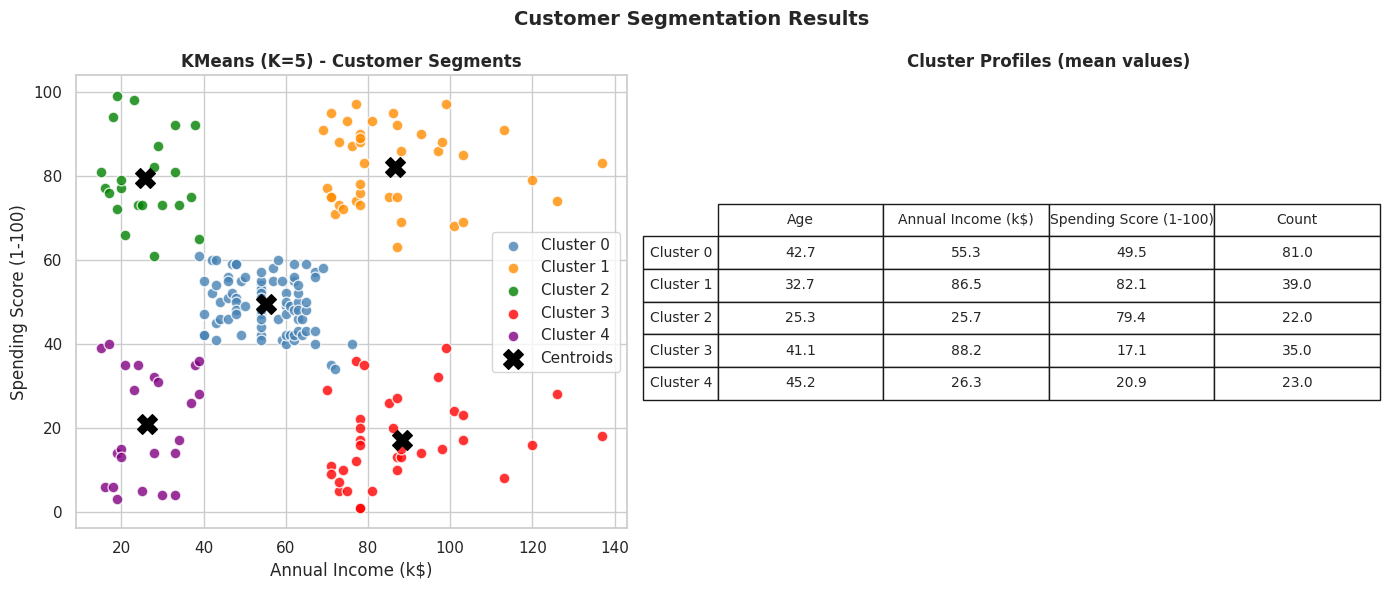

In [ ]:
# Visualise clusters in 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_cls = ['steelblue','darkorange','green','red','purple','brown']
for cluster_id in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == cluster_id
    axes[0].scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        s=60, label=f'Cluster {cluster_id}',
        color=colors_cls[cluster_id], alpha=0.8, edgecolors='white'
    )

# Plot centroids (inverse transform from scaled space)
centroids_orig = scaler_2d.inverse_transform(km_final.cluster_centers_)
axes[0].scatter(centroids_orig[:,0], centroids_orig[:,1],
                s=200, c='black', marker='X', zorder=5, label='Centroids')
axes[0].set_xlabel('Annual Income (k$)'); axes[0].set_ylabel('Spending Score (1-100)')
axes[0].set_title(f'KMeans (K={K_FINAL}) - Customer Segments', fontweight='bold')
axes[0].legend()

# Cluster profiles
profile = df.groupby('Cluster')[FEATURES_ALL].mean().round(1)
profile['Count'] = df['Cluster'].value_counts().sort_index()
axes[1].axis('off')
table = axes[1].table(cellText=profile.values, colLabels=profile.columns,
                       rowLabels=[f'Cluster {i}' for i in profile.index],
                       cellLoc='center', loc='center')
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1.2, 2.0)
axes[1].set_title('Cluster Profiles (mean values)', fontweight='bold')

plt.suptitle('Customer Segmentation Results', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [ ]:
# Business interpretation of clusters
print('=== CLUSTER BUSINESS INTERPRETATION ===')
print()
labels_map = {
    0: 'High Income, Low Spending  -> Careful savers. Target with investment products.',
    1: 'Low Income, Low Spending   -> Budget shoppers. Discount campaigns work best.',
    2: 'Average Income, Average Spending -> Standard customers. Loyalty programs.',
    3: 'High Income, High Spending -> Prime customers. VIP service, premium products.',
    4: 'Low Income, High Spending  -> Impulsive spenders. Risk of debt; credit offers.',
}
profile_full = df.groupby('Cluster')[FEATURES_2D].mean().round(1)
for cid in sorted(df['Cluster'].unique()):
    inc  = profile_full.loc[cid, 'Annual Income (k$)']
    spen = profile_full.loc[cid, 'Spending Score (1-100)']
    cnt  = (df['Cluster']==cid).sum()
    interp = labels_map.get(cid, 'Profile segment')
    print(f'  Cluster {cid} (n={cnt}): Income=${inc}k  Score={spen}')
    print(f'             -> {interp}')
    print()

=== CLUSTER BUSINESS INTERPRETATION ===

  Cluster 0 (n=81): Income=$55.3k  Score=49.5
             -> High Income, Low Spending  -> Careful savers. Target with investment products.

  Cluster 1 (n=39): Income=$86.5k  Score=82.1
             -> Low Income, Low Spending   -> Budget shoppers. Discount campaigns work best.

  Cluster 2 (n=22): Income=$25.7k  Score=79.4
             -> Average Income, Average Spending -> Standard customers. Loyalty programs.

  Cluster 3 (n=35): Income=$88.2k  Score=17.1
             -> High Income, High Spending -> Prime customers. VIP service, premium products.

  Cluster 4 (n=23): Income=$26.3k  Score=20.9
             -> Low Income, High Spending  -> Impulsive spenders. Risk of debt; credit offers.



## Section 6 - PCA for Cluster Visualisation

When we have more than 2 features, we can't directly plot clusters.
PCA projects data to 2D while preserving as much variance as possible.

**Important:** PCA here is used only for VISUALISATION, not for modelling.
We cluster on the original (scaled) features, then project to 2D to plot.

In [ ]:
training_start = time.time()

km_all = KMeans(
    n_clusters=K_FINAL,
    init='k-means++',
    n_init=20,
    random_state=42
)

km_all.fit(X_all_s)

training_end = time.time()
pca_kmeans_training_time = training_end - training_start

prediction_start = time.time()

labels_all = km_all.predict(X_all_s)

prediction_end = time.time()
pca_kmeans_prediction_time = prediction_end - prediction_start

with open("kmeans_pca.pkl", "wb") as f:
    pickle.dump(km_all, f)

pca_kmeans_model_size = os.path.getsize("kmeans_pca.pkl") / (1024**2)

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_all_s)

print(f"Variance explained by 2 PCs: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")

print("=" * 60)
print(f"Training Time   : {pca_kmeans_training_time:.4f} sec")
print(f"Prediction Time : {pca_kmeans_prediction_time:.6f} sec")
print(f"Model Size      : {pca_kmeans_model_size:.6f} MB")
print("=" * 60)

Variance explained by 2 PCs: 77.57%
Training Time   : 0.0405 sec
Prediction Time : 0.000481 sec
Model Size      : 0.001451 MB


## Section 7 - DBSCAN

KMeans requires you to specify K and assumes spherical clusters.
**DBSCAN** finds clusters as dense regions separated by sparse regions.
No K needed. It automatically labels outliers as -1.

**Choosing eps:** Plot the 4th-nearest-neighbour distance for each point,
sorted ascending. The 'elbow' of this plot is a good eps value.

**min_samples:** Minimum points to be a core point. Rule of thumb: 2 * n_features.

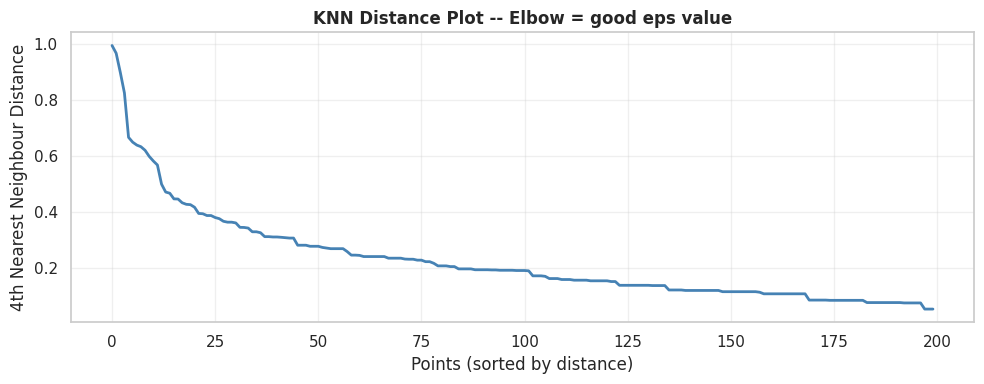

Look for the elbow -- that is your eps value.
Typical range of 4th-NN distances: 0.05 to 0.99
Choose eps at the elbow, roughly where the curve bends sharply.


In [ ]:
# Choose eps using KNN distance plot
nn = NearestNeighbors(n_neighbors=4)
nn.fit(X_2d_s)
distances, _ = nn.kneighbors(X_2d_s)
distances_sorted = np.sort(distances[:, 3])[::-1]  # 4th NN distance, descending

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(distances_sorted, 'steelblue', linewidth=2)
ax.set_xlabel('Points (sorted by distance)')
ax.set_ylabel('4th Nearest Neighbour Distance')
ax.set_title('KNN Distance Plot -- Elbow = good eps value', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print('Look for the elbow -- that is your eps value.')
print(f'Typical range of 4th-NN distances: {distances_sorted.min():.2f} to {distances_sorted.max():.2f}')
print('Choose eps at the elbow, roughly where the curve bends sharply.')

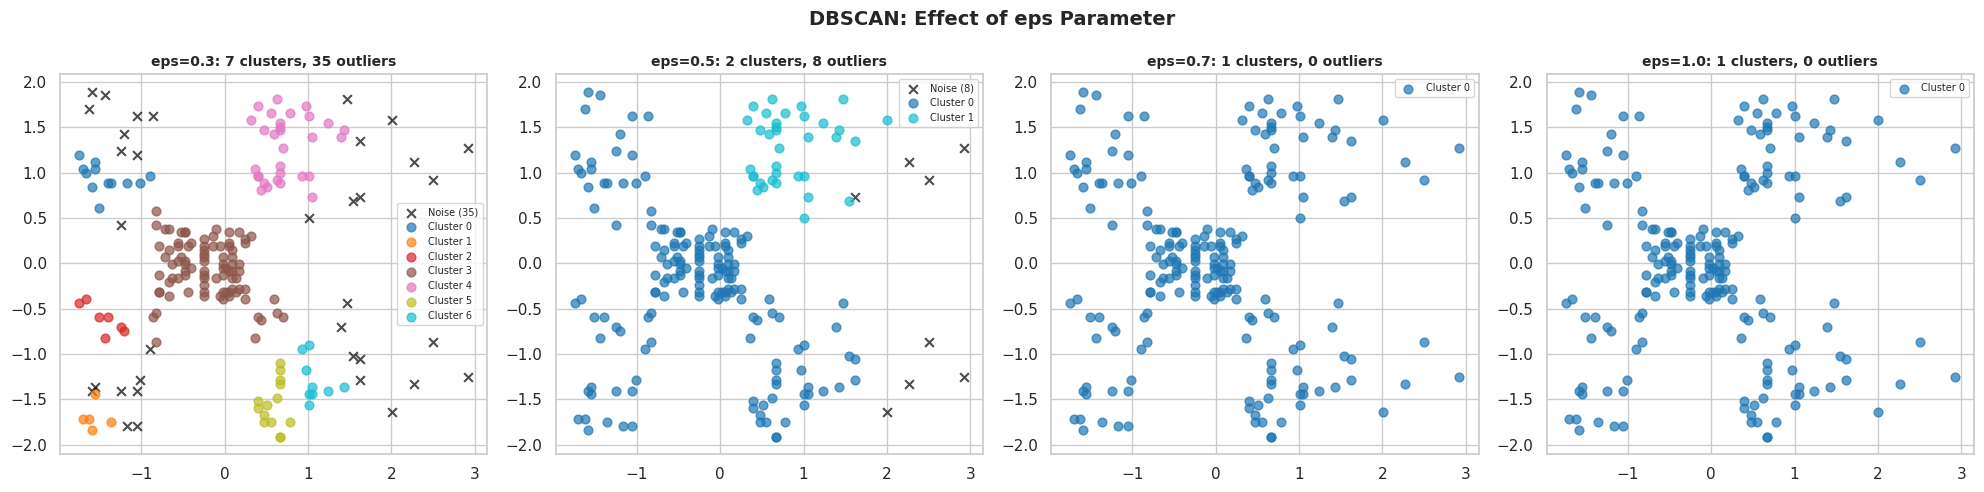

Observations:
  eps=0.3: too small -> most points are noise (too strict)
  eps=0.5: looks right -> good separation with few noise points
  eps=0.7: merging clusters -> too lenient
  eps=1.0: one big cluster -> eps too large, everything merged


In [ ]:
# Run DBSCAN with a few eps values and compare
eps_values = [0.3, 0.5, 0.7, 1.0]

fig, axes = plt.subplots(1, len(eps_values), figsize=(20, 5))

for ax, eps in zip(axes, eps_values):
    db = DBSCAN(eps=eps, min_samples=5)
    db.fit(X_2d_s)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = list(labels).count(-1)

    unique_labels = set(labels)
    cmap = plt.cm.tab10
    for lbl in sorted(unique_labels):
        mask   = labels == lbl
        color  = 'black' if lbl == -1 else cmap(lbl / max(max(unique_labels), 1))
        marker = 'x' if lbl == -1 else 'o'
        label  = f'Noise ({n_noise})' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(X_2d_s[mask, 0], X_2d_s[mask, 1],
                   c=[color], s=40, marker=marker, label=label, alpha=0.7)
    ax.set_title(f'eps={eps}: {n_clusters} clusters, {n_noise} outliers',
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('DBSCAN: Effect of eps Parameter', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('Observations:')
print('  eps=0.3: too small -> most points are noise (too strict)')
print('  eps=0.5: looks right -> good separation with few noise points')
print('  eps=0.7: merging clusters -> too lenient')
print('  eps=1.0: one big cluster -> eps too large, everything merged')

In [ ]:
training_start = time.time()

best_eps = 0.5

db_best = DBSCAN(
    eps=best_eps,
    min_samples=5
)

db_best.fit(X_2d_s)

training_end = time.time()
dbscan_training_time = training_end - training_start

cpu_after = psutil.cpu_percent(interval=1)
memory_after = process.memory_info().rss / (1024**2)

prediction_start = time.time()

db_labels = db_best.fit_predict(X_2d_s)

prediction_end = time.time()
dbscan_prediction_time = prediction_end - prediction_start

with open("dbscan.pkl", "wb") as f:
    pickle.dump(db_best, f)

dbscan_model_size = os.path.getsize("dbscan.pkl") / (1024**2)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)

print("=" * 60)
print("DBSCAN")
print("=" * 60)
print(f"Clusters Found  : {n_clusters}")
print(f"Noise Points    : {n_noise}")
print(f"Training Time   : {dbscan_training_time:.4f} sec")
print(f"Prediction Time : {dbscan_prediction_time:.6f} sec")
print(f"CPU Usage       : {cpu_after:.2f}%")
print(f"Memory Usage    : {memory_after:.2f} MB")
print(f"Model Size      : {dbscan_model_size:.6f} MB")

DBSCAN
Clusters Found  : 2
Noise Points    : 8
Training Time   : 0.0099 sec
Prediction Time : 0.002672 sec
CPU Usage       : 0.50%
Memory Usage    : 277.25 MB
Model Size      : 0.006245 MB


In [ ]:
# Summary comparison: KMeans vs DBSCAN
print('=' * 60)
print('  DAY 3 NOTEBOOK 3 - FINAL RESULTS')
print('  Dataset: Mall Customers (200 customers, 3 features)')
print('=' * 60)
print()
print('KMeans:')
km_sil = silhouette_score(X_2d_s, km_final.labels_)
print(f'  K={K_FINAL} clusters, Silhouette={km_sil:.4f}')
print(f'  No outliers identified (every point assigned to a cluster)')
print(f'  Assumes spherical, equal-size clusters')
print()
print('DBSCAN:')
print(f'  {n_clusters} clusters found automatically (no K needed)')
print(f'  {n_noise} outlier/noise points identified')
print(f'  Handles arbitrary shapes; finds anomalies')
print()
print('PCA:')
print(f'  {n_95} component(s) capture 95% of variance in the 3-feature dataset')
print(f'  Used for cluster visualisation when features > 2')
print()
print('Key lessons:')
print('  1. Always scale before any distance-based algorithm (KMeans, DBSCAN)')
print('  2. Elbow + Silhouette together are more reliable than either alone')
print('  3. DBSCAN eps requires domain judgment -- plot KNN distances first')
print('  4. Outliers from DBSCAN (-1) are often the most interesting customers')
print('  5. PCA for visualisation != PCA for modelling -- never confuse the two')

  DAY 3 NOTEBOOK 3 - FINAL RESULTS
  Dataset: Mall Customers (200 customers, 3 features)

KMeans:
  K=5 clusters, Silhouette=0.5547
  No outliers identified (every point assigned to a cluster)
  Assumes spherical, equal-size clusters

DBSCAN:
  2 clusters found automatically (no K needed)
  8 outlier/noise points identified
  Handles arbitrary shapes; finds anomalies

PCA:
  3 component(s) capture 95% of variance in the 3-feature dataset
  Used for cluster visualisation when features > 2

Key lessons:
  1. Always scale before any distance-based algorithm (KMeans, DBSCAN)
  2. Elbow + Silhouette together are more reliable than either alone
  3. DBSCAN eps requires domain judgment -- plot KNN distances first
  4. Outliers from DBSCAN (-1) are often the most interesting customers
  5. PCA for visualisation != PCA for modelling -- never confuse the two


In [ ]:
print("=" * 80)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 80)

print("\nK-Means")
print(f"Training Time   : {kmeans_training_time:.4f} sec")
print(f"Prediction Time : {kmeans_prediction_time:.6f} sec")
print(f"Model Size      : {kmeans_model_size:.6f} MB")

print("\nK-Means + PCA")
print(f"Training Time   : {pca_kmeans_training_time:.4f} sec")
print(f"Prediction Time : {pca_kmeans_prediction_time:.6f} sec")
print(f"Model Size      : {pca_kmeans_model_size:.6f} MB")

print("\nDBSCAN")
print(f"Training Time   : {dbscan_training_time:.4f} sec")
print(f"Prediction Time : {dbscan_prediction_time:.6f} sec")
print(f"Model Size      : {dbscan_model_size:.6f} MB")

print("\nSystem Resources")
print(f"CPU Usage       : {cpu_after:.2f}%")
print(f"Memory Usage    : {memory_after:.2f} MB")

print("=" * 80)

FINAL PERFORMANCE SUMMARY

K-Means
Training Time   : 0.0340 sec
Prediction Time : 0.000698 sec
Model Size      : 0.001412 MB

K-Means + PCA
Training Time   : 0.0405 sec
Prediction Time : 0.000481 sec
Model Size      : 0.001451 MB

DBSCAN
Training Time   : 0.0099 sec
Prediction Time : 0.002672 sec
Model Size      : 0.006245 MB

System Resources
CPU Usage       : 0.50%
Memory Usage    : 277.25 MB
